# **EDA For Bank churn prediction**

## **1. DATA**

### data is taken from kaggle https://www.kaggle.com/datasets/gauravtopre/bank-customer-churn-dataset

### **About DataSet**
#### it consists on 
1. customer_id, **A unique identification number assigned to each bank client**.
2. credit_score, **A numerical score reflecting the customer's creditworthiness.**
3. country, **The geographic location or residential country of the customer.**
4. gender, **The customer's gender**.
5. age, **age of customer**.
6. tenure, **The number of years the customer has been actively doing business with the bank** .
7. balance, **The amount of money currently held in the customer's primary bank account.**
8. products_number, **The total number of different bank products or services (e.g., savings account, loan, investment fund) the customer utilizes.**
9. credit_card, **A binary indicator showing whether the customer owns a credit card issued by the bank.**
10. active_member, **A binary indicator showing whether the customer frequently uses bank services or logs into their account (1 for active, 0 for inactive).**
11. estimated_salary, **An estimated annual income calculated or reported for the customer.**
12. churn , **1 for churn and 0 for not left**

### import libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [3]:
# importing the data
df = pd.read_csv(r'Data\churn.csv')

In [4]:
# getting first five row 
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
# getting info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  str    
 3   gender            10000 non-null  str    
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), str(2)
memory usage: 937.6 KB


In [6]:
# shape of data
df.shape

(10000, 12)

*data consists on 12 columns and 10k rows*
- some of the attributes are str, float and int data types

In [7]:
print('Number of row in churn dataset are',df.shape[0])

Number of row in churn dataset are 10000


In [8]:
print('Number of columns in churn dataset are',df.shape[1])

Number of columns in churn dataset are 12


In [9]:
print('columns in churn dataset are',df.columns.tolist())

columns in churn dataset are ['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'churn']


In [10]:
# checking null values
df.isna().sum()

customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

In [11]:
# checking dupliccates columnm 
df.duplicated().sum()

np.int64(0)

## no duplicates column in dataset

### *there is no null values in data**

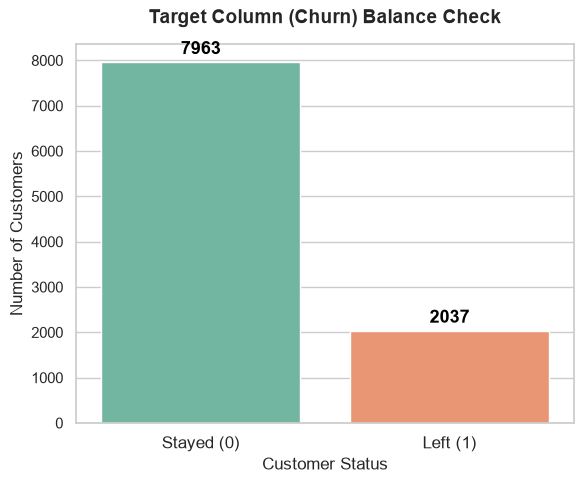

In [80]:
# check the dataset is balance or not 

# Set a clean visual theme
sns.set_theme(style="whitegrid")
plt.figure(figsize=(6, 5))

ax = sns.countplot(data=df, x='churn', hue='churn', legend=False, palette='Set2')

for container in ax.containers:
    ax.bar_label(container, color='black', size=13, fontweight='bold', padding=3)

plt.title("Target Column (Churn) Balance Check", fontsize=14, fontweight='bold', pad=15)
plt.xticks(ticks=[0, 1], labels=['Stayed (0)', 'Left (1)'], fontsize=12)
plt.xlabel("Customer Status", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

plt.tight_layout()
plt.show()


### *the dataset is imblance where not churns are very more than left, it will be balance when model is trained*


In [12]:
# getting objec column 
df_cat_column = df.select_dtypes(include='O')
df_cat_column

,country,gender
0,France,Female
1,Spain,Female
2,France,Female
3,France,Female
4,Spain,Female
...,...,...
9995,France,Male
9996,France,Male
9997,France,Female
9998,Germany,Male


### we have only 2 columns of obj dtypes

In [13]:
# let explore further 
df_cat_column['country'].value_counts()

country
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

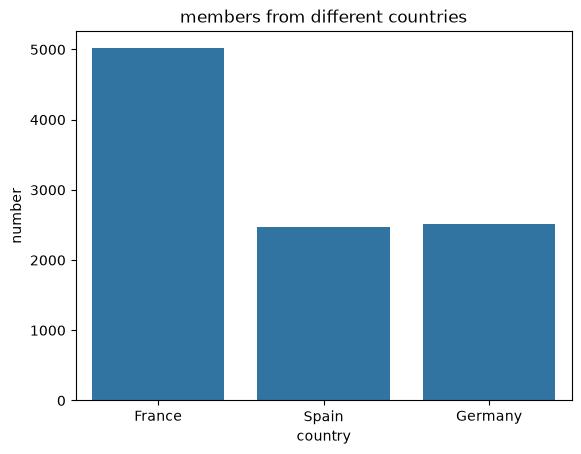

In [14]:
sns.countplot(x='country',data=df)
plt.ylabel("number")
plt.title('members from different countries')
plt.show()

## number of member from each country are
- France 5014
- Germany 2509
- Spain 2477



In [15]:
# let analyzed gender column 
df['gender'].value_counts()

gender
Male      5457
Female    4543
Name: count, dtype: int64

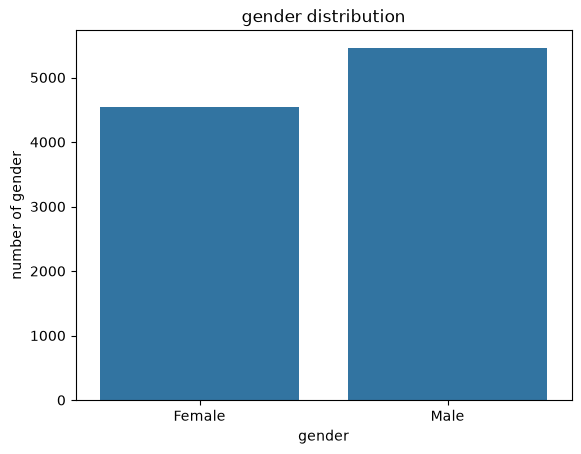

In [16]:
### male and female distribution
sns.countplot(x='gender',data=df)
plt.ylabel('number of gender')
plt.title('gender distribution')
plt.show()

## males are more than female
- males = 5457
- female = 4543

In [17]:
df[['country','gender']].value_counts()

country  gender
France   Male      2753
         Female    2261
Spain    Male      1388
Germany  Male      1316
         Female    1193
Spain    Female    1089
Name: count, dtype: int64

### Gender distribution among each country 
1. France male = 2753, female = 2261
2. Germany, male = 1316, female = 1193
3. spain, male = 1388, female = 1089

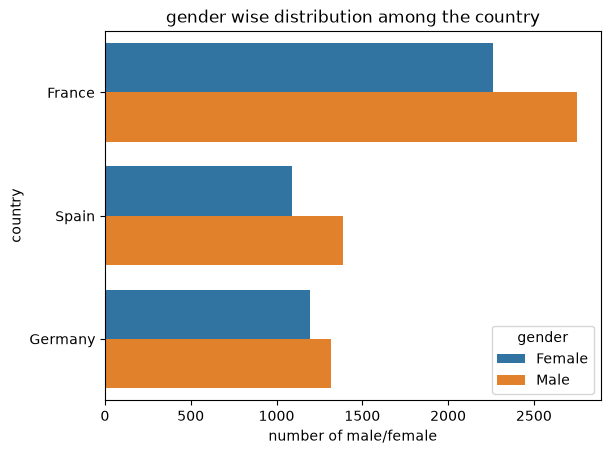

In [18]:
sns.countplot(y='country',hue = 'gender', data=df)
plt.xlabel('number of male/female')
plt.title('gender wise distribution among the country')
plt.show()

### now to see how many churn according to each country

In [19]:
df[['country','churn']].value_counts().reset_index()

,country,churn,count
0,France,0,4204
1,Spain,0,2064
2,Germany,0,1695
3,Germany,1,814
4,France,1,810
5,Spain,1,413


- more churn is from germany and less from Spain 
### not churn 
1. France = 4204
2. Spain =2064
3. Germany = 1695
### churn
1. Germany = 814
2. France = 810
3. Spain = 413



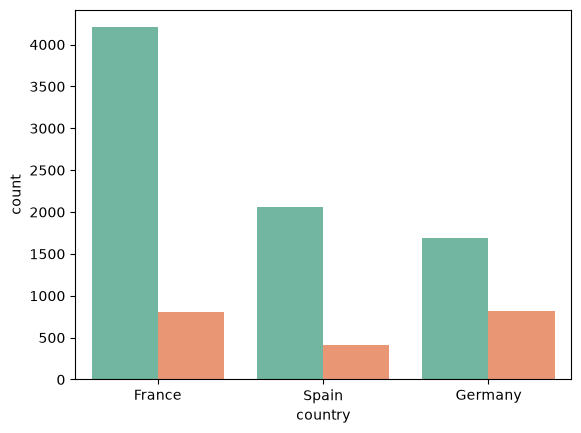

In [20]:
sns.countplot(x='country',hue='churn',data=df,legend=False, palette="Set2")
plt.show()

### *more churned is from Germany and Non Churned is from France*

In [21]:
df_counts= df[['country','gender','churn']].value_counts().reset_index()
df_counts

,country,gender,churn,count
0,France,Male,0,2403
1,France,Female,0,1801
2,Spain,Male,0,1206
3,Germany,Male,0,950
4,Spain,Female,0,858
5,Germany,Female,0,745
6,France,Female,1,460
7,Germany,Female,1,448
8,Germany,Male,1,366
9,France,Male,1,350


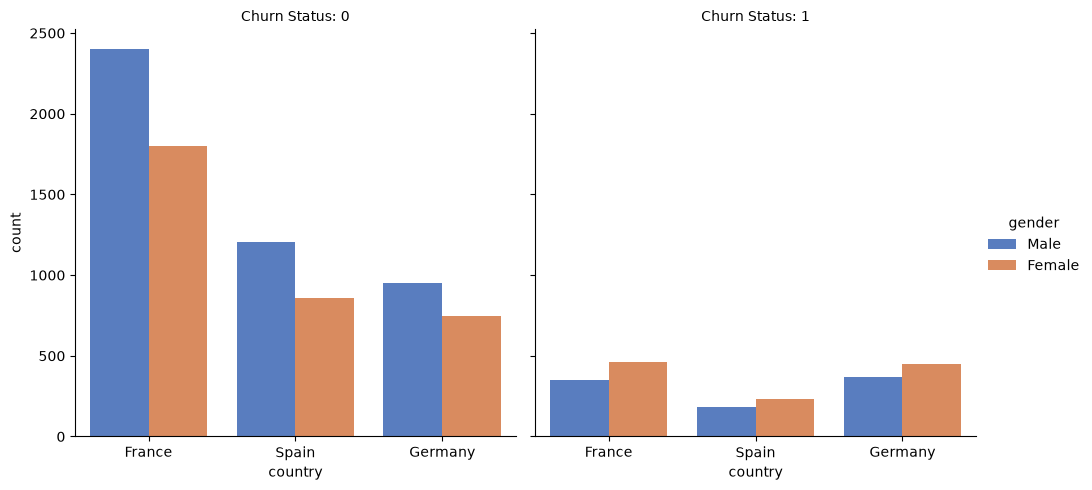

In [22]:
g = sns.catplot(
    data=df_counts,
    kind="bar",
    x="country",
    y="count",
    hue="gender",
    col="churn",
    palette="muted",
)
g.set_titles("Churn Status: {col_name}")
plt.show()

## NOt churn 
1. France , Male = 2403, female = 1801
2. Spain : Male = 1206, female = 858
3. Germany: Male = 950, Female = 745
## Churn
1. France: MAle = 350, female = 460
2. Spain : Male = 182, female = 231
3. Germany : Male = 366, female =488

## **checking for non obj columns**

In [23]:
df_num = df.select_dtypes(exclude='O')
df_num.head()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,43,2,125510.82,1,1,1,79084.10,0


In [24]:
print(f'the number of non obj data type columns are',len(df_num.columns))

the number of non obj data type columns are 10


In [25]:
# get statiscal analysis
df_num.describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


# **Analysis**
1. credit_score: The average customer score is 650, ranging from a low of 350 to a perfect ceiling of 850.
2. age: The bank's customer base is relatively young, with an average age of 39 and 75% of clients under 44.
3. tenure: On average, clients have been with the bank for 5 years, scaling up to a maximum of 10.
4. balance: Account balances peak near $250,898, but a critical 25% or more of the customer base holds a balance of exactly zero.
5. products_number: Most customers utilize only 1 or 2 banking products, while the absolute maximum any single client holds is 4.
5. credit_card: A clear majority of the client base is equipped with a bank-issued credit card, sitting at 70.5%.
6. active_member: The customer base is split almost evenly down the middle, with only 51.5% classified as actively engaged.
7. estimated_salary: Customer salaries are spread out evenly across the board, ranging from a negligible $11.58 up to roughly $200,000.
8. churn: The dataset reveals a baseline turnover rate where exactly 20.37% of the recorded bank customers chose to leave.

In [26]:
# cehckign for outliers in non obj columns
df_col = df_num.drop(['customer_id','churn'],axis = 1).columns
df_col

Index(['credit_score', 'age', 'tenure', 'balance', 'products_number',
       'credit_card', 'active_member', 'estimated_salary'],
      dtype='str')

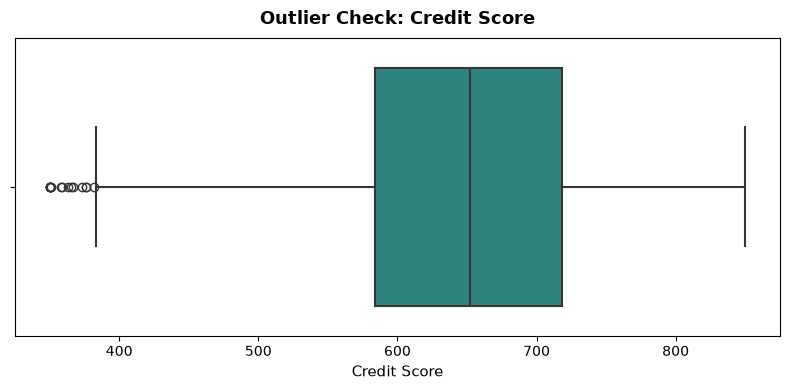

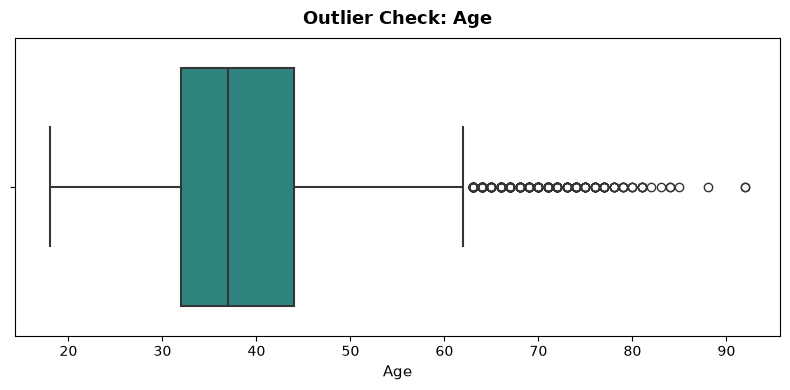

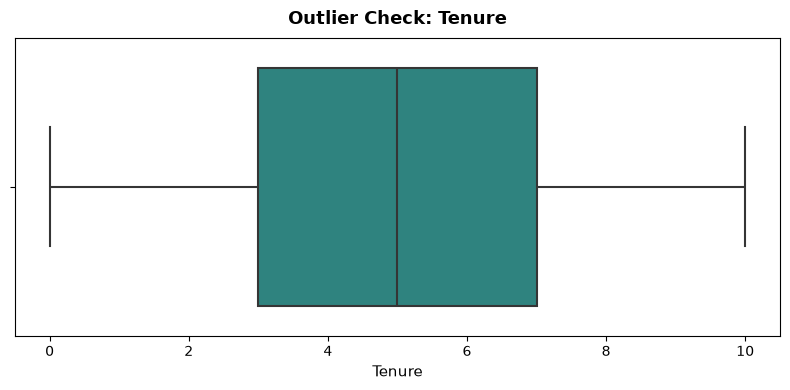

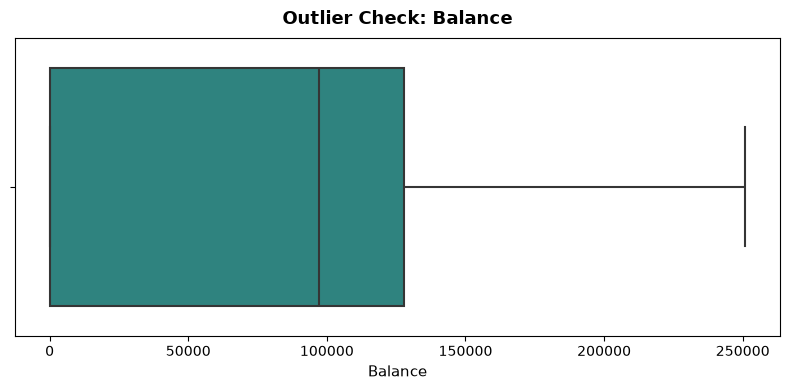

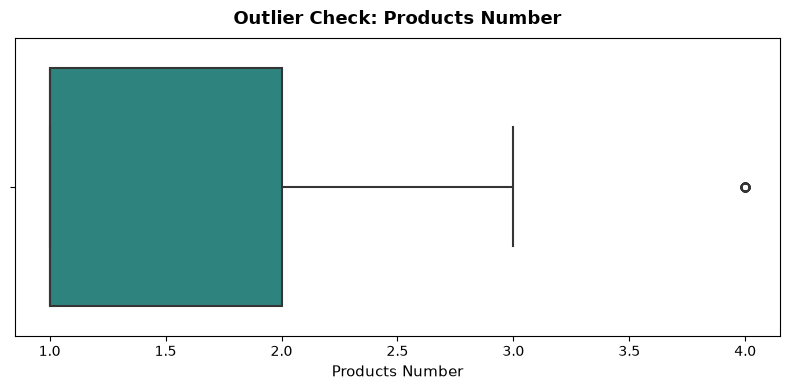

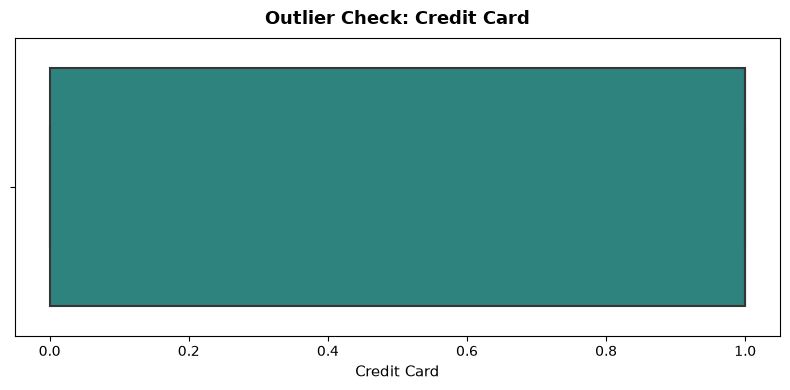

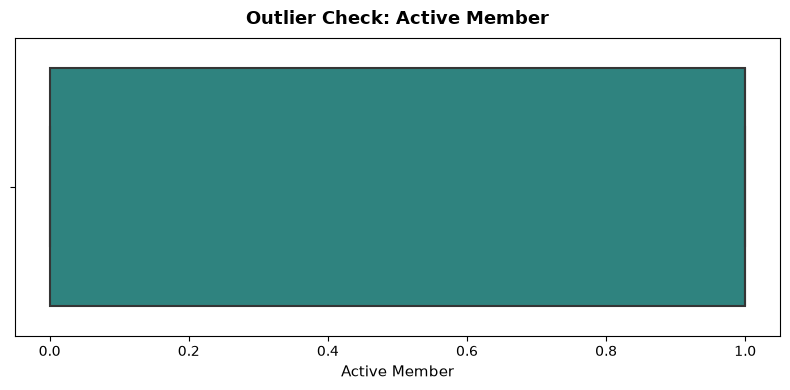

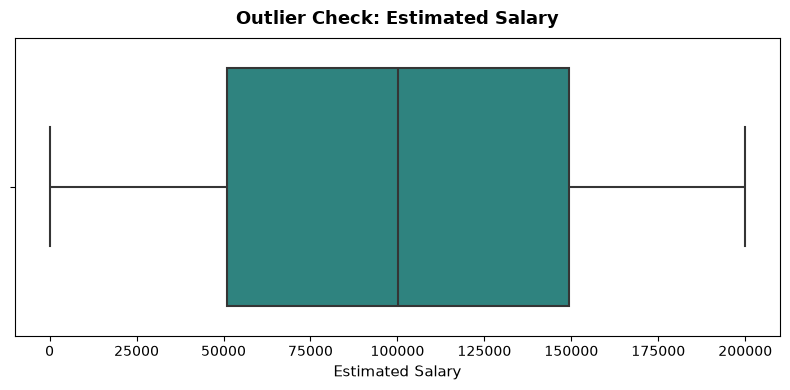

In [27]:
for col in df_col:
    plt.figure(figsize=(8, 4))  # Sets a clean aspect ratio for each chart
    
    # Create the boxplot with a vibrant color gradient
    sns.boxplot(
        data=df, 
        x=col,  
        legend=False, 
        palette="viridis", 
        linewidth=1.5
    )
    
    # Format titles dynamically by replacing underscores with spaces
    plt.title(f"Outlier Check: {col.replace('_', ' ').title()}", fontsize=13, fontweight='bold', pad=10)
    plt.xlabel(col.replace('_', ' ').title(), fontsize=11)
    
    plt.tight_layout()
    plt.show()

In [28]:
#getting those column that have outliers
# 1. Define your numerical continuous columns
numerical_cols = ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary']

outlier_results = {}

# 2. Loop and calculate bounds using the IQR rule
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Define standard boxplot threshold limits
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Filter rows that fall outside the healthy thresholds
    outlier_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
    
    # Only save columns that actually have outliers
    if outlier_count > 0:
        outlier_results[col] = outlier_count

# 3. Print the columns that have outliers
print("Columns with outliers:", list(outlier_results.keys()))
print("Detailed counts:", outlier_results)


Columns with outliers: ['credit_score', 'age', 'products_number']
Detailed counts: {'credit_score': 15, 'age': 359, 'products_number': 60}


### checking credit score

In [29]:
df.credit_score.min()

np.int64(350)

In [30]:
# 15 customer that score less than 380
df[df['credit_score']<383]

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
7,15656148,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
942,15804586,376,France,Female,46,6,0.00,1,1,0,157333.69,1
1193,15779947,363,Spain,Female,28,6,146098.43,3,1,0,100615.14,1
1405,15612494,359,France,Female,44,6,128747.69,1,1,0,146955.71,1
1631,15685372,350,Spain,Male,54,1,152677.48,1,1,1,191973.49,1
1838,15758813,350,Germany,Male,39,0,109733.20,2,0,0,123602.11,1
1962,15692416,358,Spain,Female,52,8,143542.36,3,1,0,141959.11,1
2473,15679249,351,Germany,Female,57,4,163146.46,1,1,0,169621.69,1
2579,15597896,365,Germany,Male,30,0,127760.07,1,1,0,81537.85,1
8154,15791533,367,Spain,Male,42,6,93608.28,1,1,0,168816.73,1


### *the lowes credit score customer mean less than 383 those are 15 and will churn*

In [31]:
df[df['age']>62]

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
58,15623944,511,Spain,Female,66,4,0.00,1,1,0,1643.11,1
85,15805254,652,Spain,Female,75,10,0.00,2,1,1,114675.75,0
104,15804919,670,Spain,Female,65,1,0.00,1,1,1,177655.68,1
158,15589975,646,France,Female,73,6,97259.25,1,0,1,104719.66,0
181,15789669,510,France,Male,65,2,0.00,2,1,1,48071.61,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9753,15705174,656,Germany,Male,68,7,153545.11,1,1,1,186574.68,0
9765,15777067,445,France,Male,64,2,136770.67,1,0,1,43678.06,0
9832,15814690,595,Germany,Female,64,2,105736.32,1,1,1,89935.73,1
9894,15704795,521,France,Female,77,6,0.00,2,1,1,49054.10,0


greater and equal to 62 age is outlier consider

# now check either these are churn or not 

In [32]:
df[df['age']>62]['churn'].reset_index()

,index,churn
0,58,1
1,85,0
2,104,1
3,158,0
4,181,0
...,...,...
354,9753,0
355,9765,0
356,9832,1
357,9894,0


In [33]:
df[df['age']>62]['churn'].value_counts()

churn
0    286
1     73
Name: count, dtype: int64

## only 73 people will churn greater age 62

In [34]:
older_churned = df[(df['age'] > 62) & (df['churn'] == 1)]
older_churned

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
58,15623944,511,Spain,Female,66,4,0.00,1,1,0,1643.11,1
104,15804919,670,Spain,Female,65,1,0.00,1,1,1,177655.68,1
243,15596175,659,Germany,Male,67,6,117411.60,1,1,1,45071.09,1
399,15646372,616,France,Female,66,1,135842.41,1,1,0,183840.51,1
769,15685329,531,France,Female,63,1,114715.71,1,0,1,24506.95,1
...,...,...,...,...,...,...,...,...,...,...,...,...
9438,15641175,701,Germany,Male,63,3,120916.52,3,0,0,144727.45,1
9555,15655360,782,Germany,Female,72,5,148666.99,1,1,0,2605.65,1
9646,15603111,850,Spain,Male,71,10,69608.14,1,1,0,97893.40,1
9747,15775761,610,Germany,Female,69,5,86038.21,3,0,0,192743.06,1


In [35]:
group = older_churned.groupby('country')['churn'].value_counts().reset_index()
group

,country,churn,count
0,France,1,27
1,Germany,1,29
2,Spain,1,17


### older people who churned age 62 to 90 
1. Frnce =27
2. Germany = 29
3. Spain =17

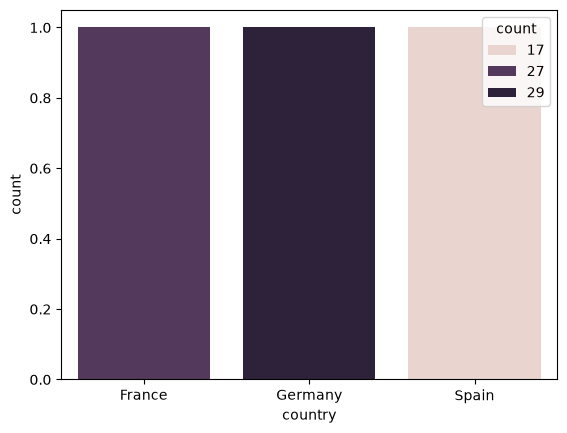

In [36]:
sns.countplot(x = 'country', hue = 'count', data = group)
plt.show()

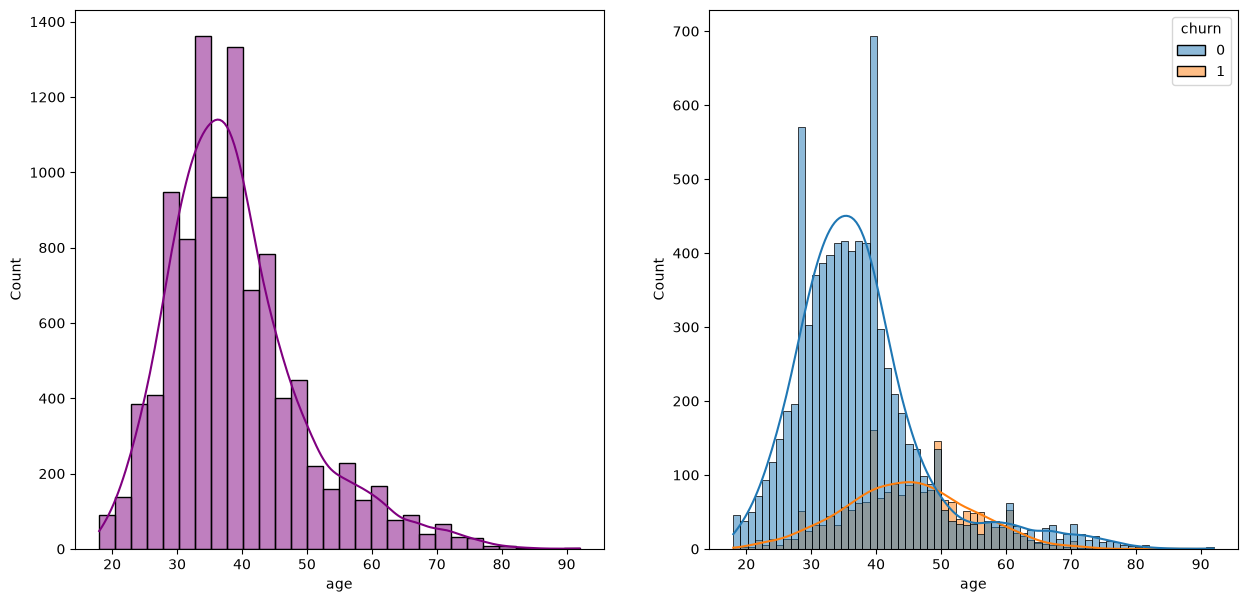

In [37]:
fig, axs = plt.subplots(1,2,figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df,x='age',bins=30,kde=True,color='purple')
plt.subplot(122)
sns.histplot(data=df,x='age',kde=True,hue='churn')
plt.show()

1. Left Plot: Overall Age Distribution
- The Shape: This is a right-skewed (positively skewed) distribution, meaning the vast majority of your bank's customers are concentrated in the younger age brackets.
- The Peak (Mode): The highest concentration of customers sits tightly between 30 and 40 years old.
- The Outliers: As age increases past 60, the bars become very short and flat, trailing all the way to 90. This perfectly visualizes why your IQR code flagged those 359 older individuals as outliers.
2. Right Plot: Age vs. Churn Breakdown
- Loyal Base (Blue): Peak retention occurs at 35 years old, dropping sharply after age 45.
- Churn Danger Zone (Orange): Losses peak significantly later, between 45 and 50 years old.
- Cross-Over Point: Customers under 40 overwhelmingly stay, while customers over 45 show a drastically higher risk of leaving.

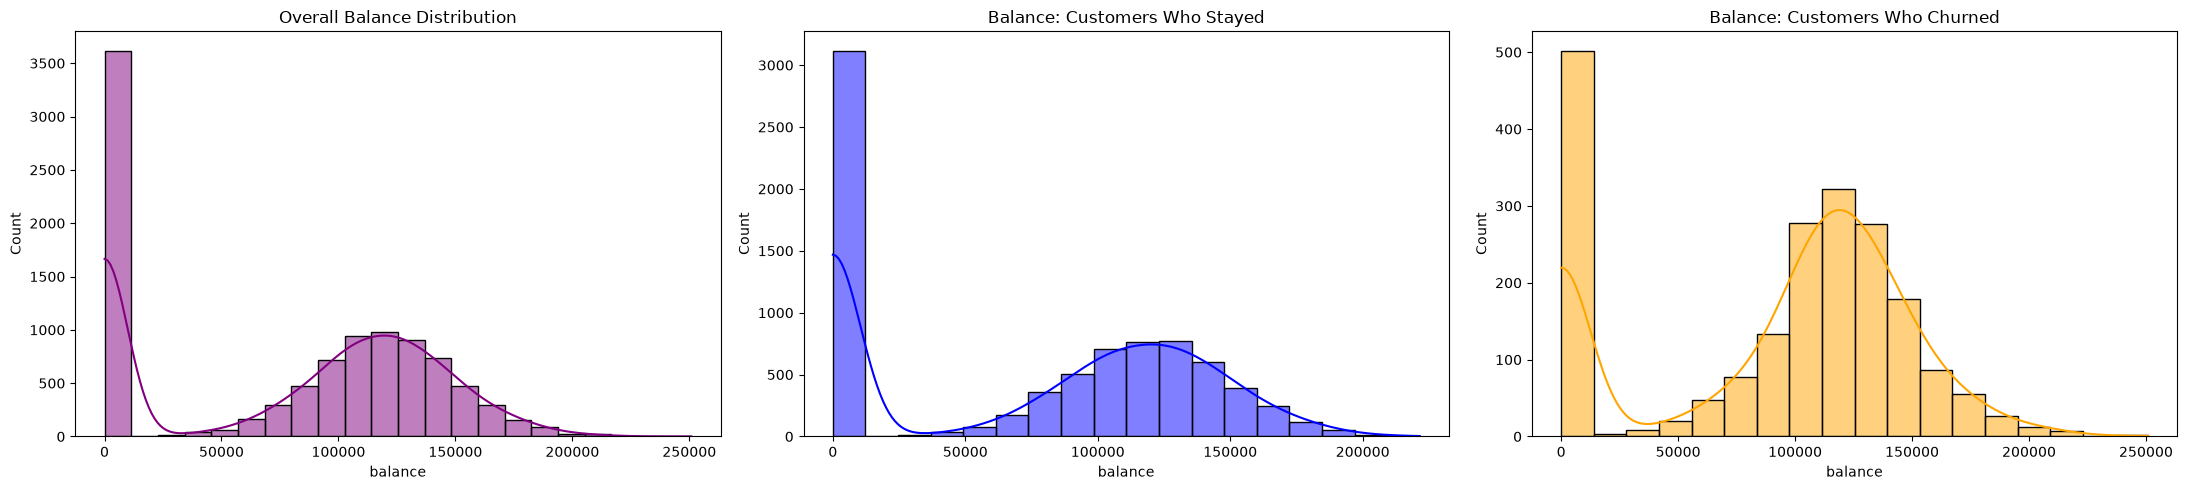

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(22, 5))

sns.histplot(data=df, x='balance', kde=True, ax=axes[0], color='purple')
axes[0].set_title('Overall Balance Distribution')

sns.histplot(data=df[df['churn'] == 0], x='balance', kde=True, ax=axes[1], color='blue')
axes[1].set_title('Balance: Customers Who Stayed')

sns.histplot(data=df[df['churn'] == 1], x='balance', kde=True, ax=axes[2], color='orange')
axes[2].set_title('Balance: Customers Who Churned')

plt.tight_layout()
plt.show()


- All three plots show a massive, identical spike at exactly zero, indicating a large portion of both active and churned clients hold empty accounts.
- Excluding the zero spike, the remaining account balances form a clean normal distribution peaking around $125,000.
- The matching shapes across both populations show that holding a high balance or an empty account does not drastically alter a customer's likelihood to churn.

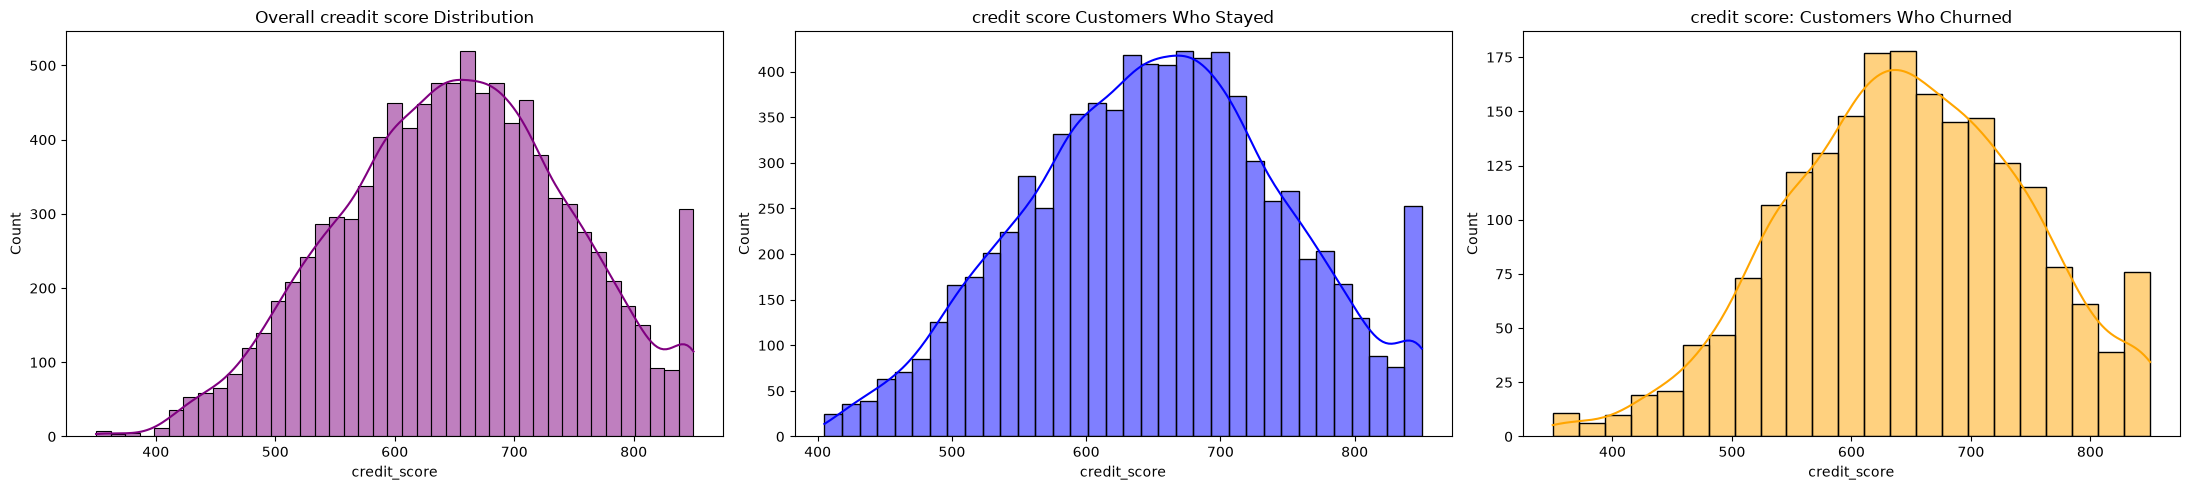

In [ ]:
# now check for credit score
fig, axes = plt.subplots(1, 3, figsize=(22, 5))

sns.histplot(data=df, x='credit_score', kde=True, ax=axes[0], color='purple')
axes[0].set_title('Overall creadit score Distribution')

sns.histplot(data=df[df['churn'] == 0], x='credit_score', kde=True, ax=axes[1], color='blue')
axes[1].set_title('credit score Customers Who Stayed')

sns.histplot(data=df[df['churn'] == 1], x='credit_score', kde=True, ax=axes[2], color='orange')
axes[2].set_title('credit score: Customers Who Churned')

plt.tight_layout()
plt.show()

- The credit score distributions follow a normal bell curve centered around 650 for both staying and leaving customers.
- A sharp visual spike occurs at the maximum score of 850 across all plots, representing a clustered group of clients with perfect credit ratings
- The shapes are highly similar, indicating that credit score alone does not strongly differentiate between clients who leave and those who stay.

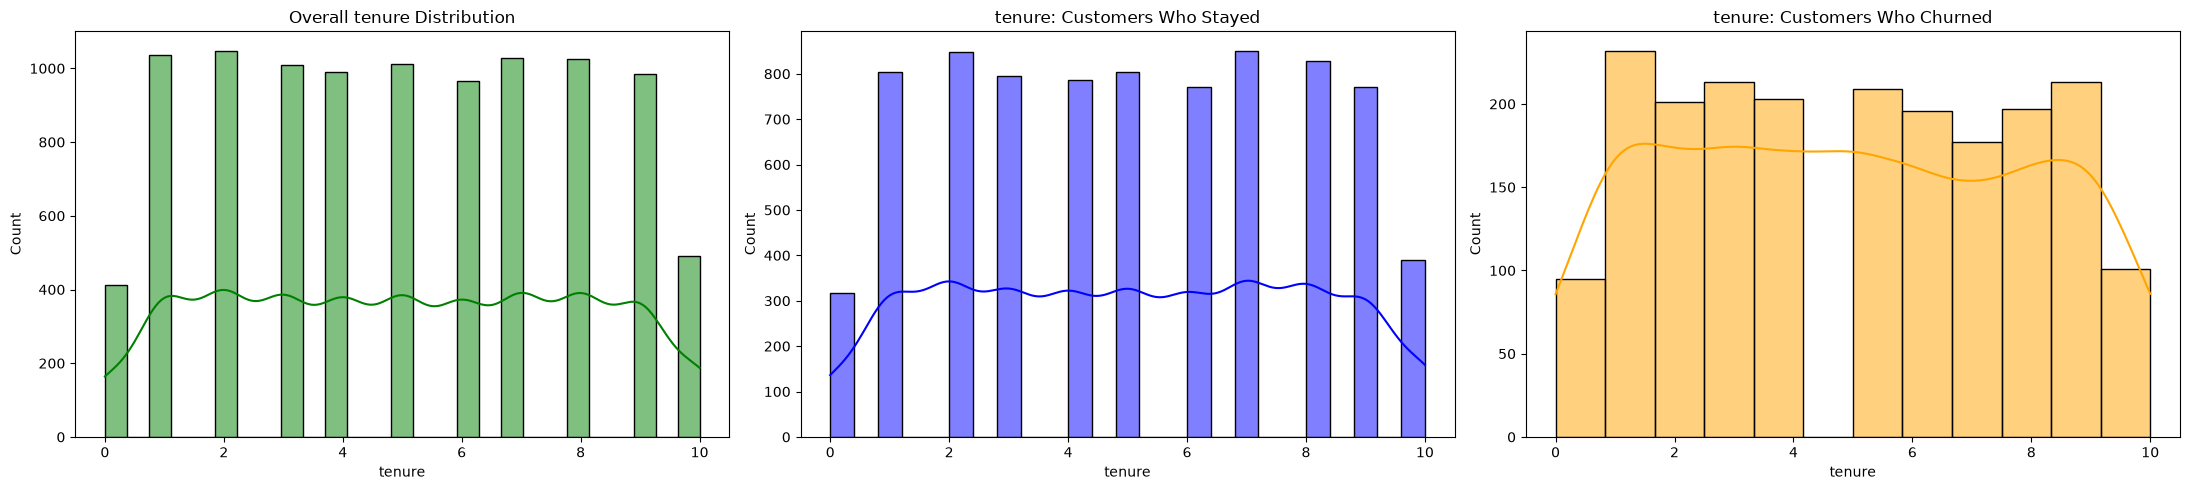

In [44]:
# checking for tenure

fig, axes = plt.subplots(1, 3, figsize=(22, 5))

sns.histplot(data=df, x='tenure', kde=True, ax=axes[0], color='green')
axes[0].set_title('Overall tenure Distribution')

sns.histplot(data=df[df['churn'] == 0], x='tenure', kde=True, ax=axes[1], color='blue')
axes[1].set_title('tenure: Customers Who Stayed')

sns.histplot(data=df[df['churn'] == 1], x='tenure', kde=True, ax=axes[2], color='orange')
axes[2].set_title('tenure: Customers Who Churned')

plt.tight_layout()
plt.show()

- identical customer counts from 1 to 9 years.
- Brand new clients (0 years) and long-term clients (10 years) show lower overall numbers because they represent transitional account boundaries.
- Because the distribution shapes match closely for both staying and leaving clients, tenure length alone does not directly trigger customer churn.

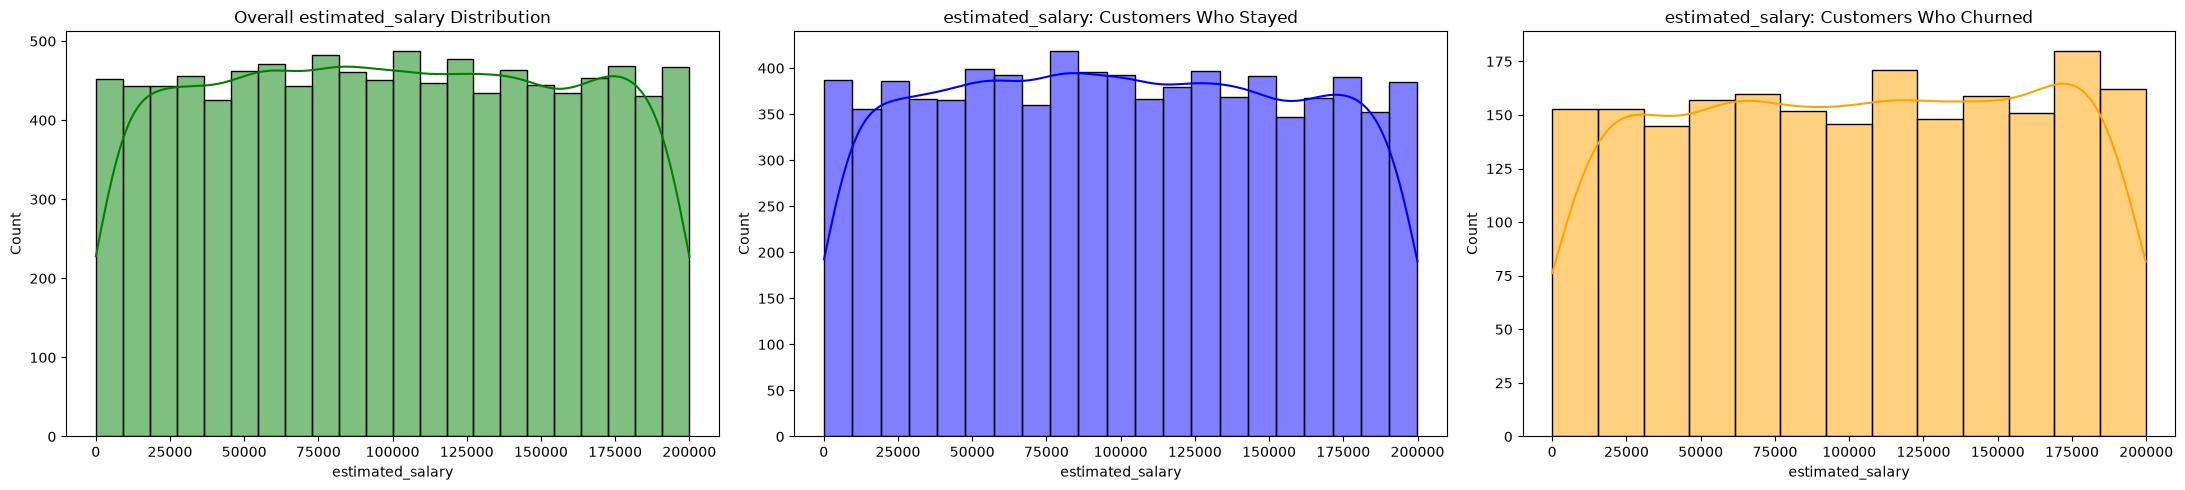

In [46]:
# for estimted salary 
fig, axes = plt.subplots(1, 3, figsize=(22, 5))

sns.histplot(data=df, x='estimated_salary', kde=True, ax=axes[0], color='green')
axes[0].set_title('Overall estimated_salary Distribution')

sns.histplot(data=df[df['churn'] == 0], x='estimated_salary', kde=True, ax=axes[1], color='blue')
axes[1].set_title('estimated_salary: Customers Who Stayed')

sns.histplot(data=df[df['churn'] == 1], x='estimated_salary', kde=True, ax=axes[2], color='orange')
axes[2].set_title('estimated_salary: Customers Who Churned')

plt.tight_layout()
plt.show()

- All three charts show a completely flat and uniform shape across all salary ranges from $0 to $200,000.
- This flat distribution means that customers with lower salaries are just as likely to stay or leave as those making high incomes.
- Because the salary patterns are identical for both groups, estimated salary carries very little predictive power for customer churn.

## UNivarient analysis of Country

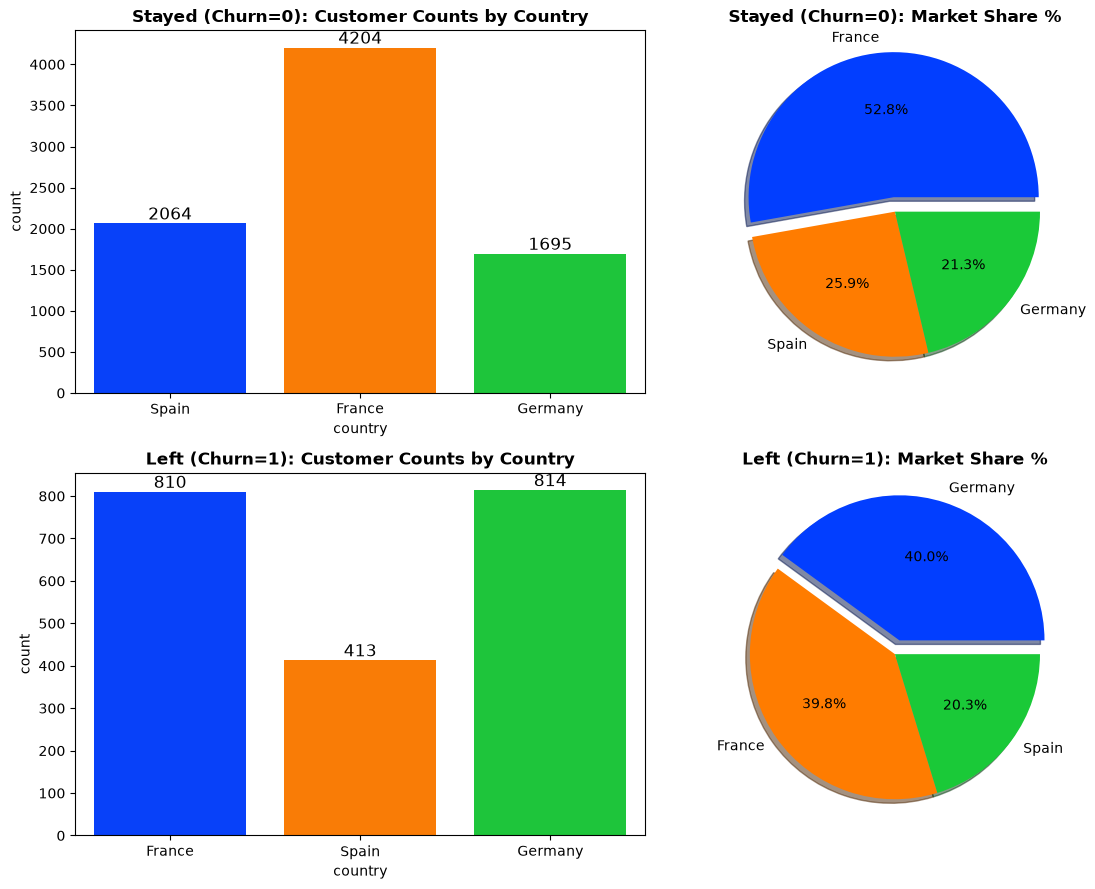

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(12, 9))


df_stayed = df[df['churn'] == 0]
df_churned = df[df['churn'] == 1]
sns.countplot(x='country', data=df_stayed, palette='bright', ax=ax[0, 0], saturation=0.95)
ax[0, 0].set_title('Stayed (Churn=0): Customer Counts by Country', fontsize=12, fontweight='bold')
for container in ax[0, 0].containers:
    ax[0, 0].bar_label(container, color='black', size=12)


ax[0, 1].pie(
    x=df_stayed['country'].value_counts(),
    labels=df_stayed['country'].value_counts().index,
    explode=[0.1, 0, 0],
    autopct='%1.1f%%',
    shadow=True,
    colors=sns.color_palette('bright')[:3]
)
ax[0, 1].set_title('Stayed (Churn=0): Market Share %', fontsize=12, fontweight='bold')

sns.countplot(x='country', data=df_churned, palette='bright', ax=ax[1, 0], saturation=0.95)
ax[1, 0].set_title('Left (Churn=1): Customer Counts by Country', fontsize=12, fontweight='bold')
for container in ax[1, 0].containers:
    ax[1, 0].bar_label(container, color='black', size=12)

# Right: Pie Chart for Churned
ax[1, 1].pie(
    x=df_churned['country'].value_counts(),
    labels=df_churned['country'].value_counts().index,
    explode=[0.1, 0, 0],
    autopct='%1.1f%%',
    shadow=True,
    colors=sns.color_palette('bright')[:3]
)
ax[1, 1].set_title('Left (Churn=1): Market Share %', fontsize=12, fontweight='bold')


plt.tight_layout()
plt.show()

## Univarient Analysis of Gender w.r.t chunr or not


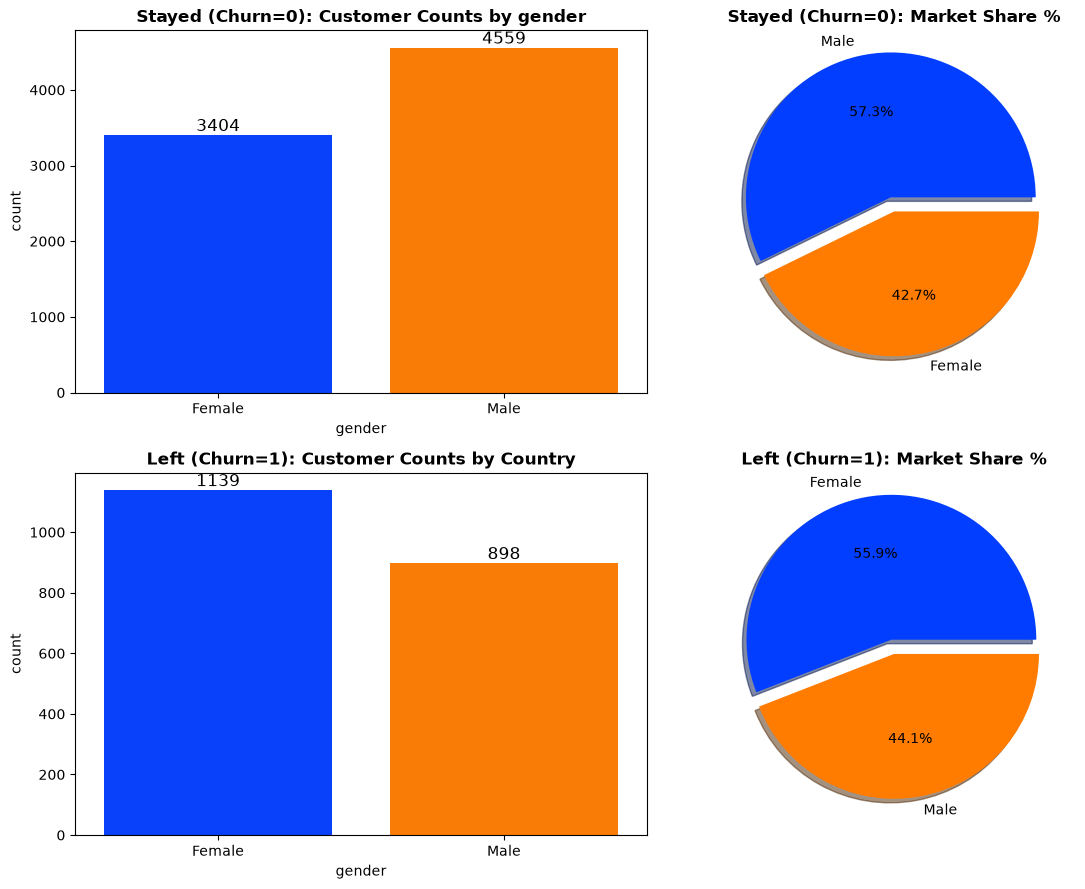

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(12, 9))


df_stayed = df[df['churn'] == 0]
df_churned = df[df['churn'] == 1]
sns.countplot(x='gender', data=df_stayed, palette='bright', ax=ax[0, 0], saturation=0.95)
ax[0, 0].set_title('Stayed (Churn=0): Customer Counts by gender', fontsize=12, fontweight='bold')
for container in ax[0, 0].containers:
    ax[0, 0].bar_label(container, color='black', size=12)


ax[0, 1].pie(
    x=df_stayed['gender'].value_counts(),
    labels=df_stayed['gender'].value_counts().index,
    explode=[0.1, 0],
    autopct='%1.1f%%',
    shadow=True,
    colors=sns.color_palette('bright')[:3]
)
ax[0, 1].set_title('Stayed (Churn=0): Market Share %', fontsize=12, fontweight='bold')

sns.countplot(x='gender', data=df_churned, palette='bright', ax=ax[1, 0], saturation=0.95)
ax[1, 0].set_title('Left (Churn=1): Customer Counts by Country', fontsize=12, fontweight='bold')
for container in ax[1, 0].containers:
    ax[1, 0].bar_label(container, color='black', size=12)

# Right: Pie Chart for Churned
ax[1, 1].pie(
    x=df_churned['gender'].value_counts(),
    labels=df_churned['gender'].value_counts().index,
    explode=[0.1, 0],
    autopct='%1.1f%%',
    shadow=True,
    colors=sns.color_palette('bright')[:3]
)
ax[1, 1].set_title('Left (Churn=1): Market Share %', fontsize=12, fontweight='bold')


plt.tight_layout()
plt.show()

### IMpect of balance on churn

In [65]:
baln = df[df['churn']==1]['balance'].reset_index().sort_values(by='balance',ascending=False)

In [67]:
print(baln.balance.min())
print(baln.balance.max())

0.0
250898.09


In [68]:
df.balance.max()

np.float64(250898.09)

 **there is no well defined impact of blance on churn , even highest blance is also churn and lowest as well**

**checking impact of salary on churn**

In [71]:
salary = df[df['churn']==1]['estimated_salary'].reset_index().sort_values(by='estimated_salary',ascending=False)
salary

,index,estimated_salary
1668,8088,199808.10
24,118,199725.39
956,4547,199693.84
776,3658,199378.58
43,206,199304.74
...,...,...
80,393,417.41
313,1462,236.45
1560,7565,123.07
1859,9010,91.75


In [72]:
print(df.estimated_salary.min())
print(df.estimated_salary.max())


11.58
199992.48


**so no proper impact of lower and higher salary on churn rate**

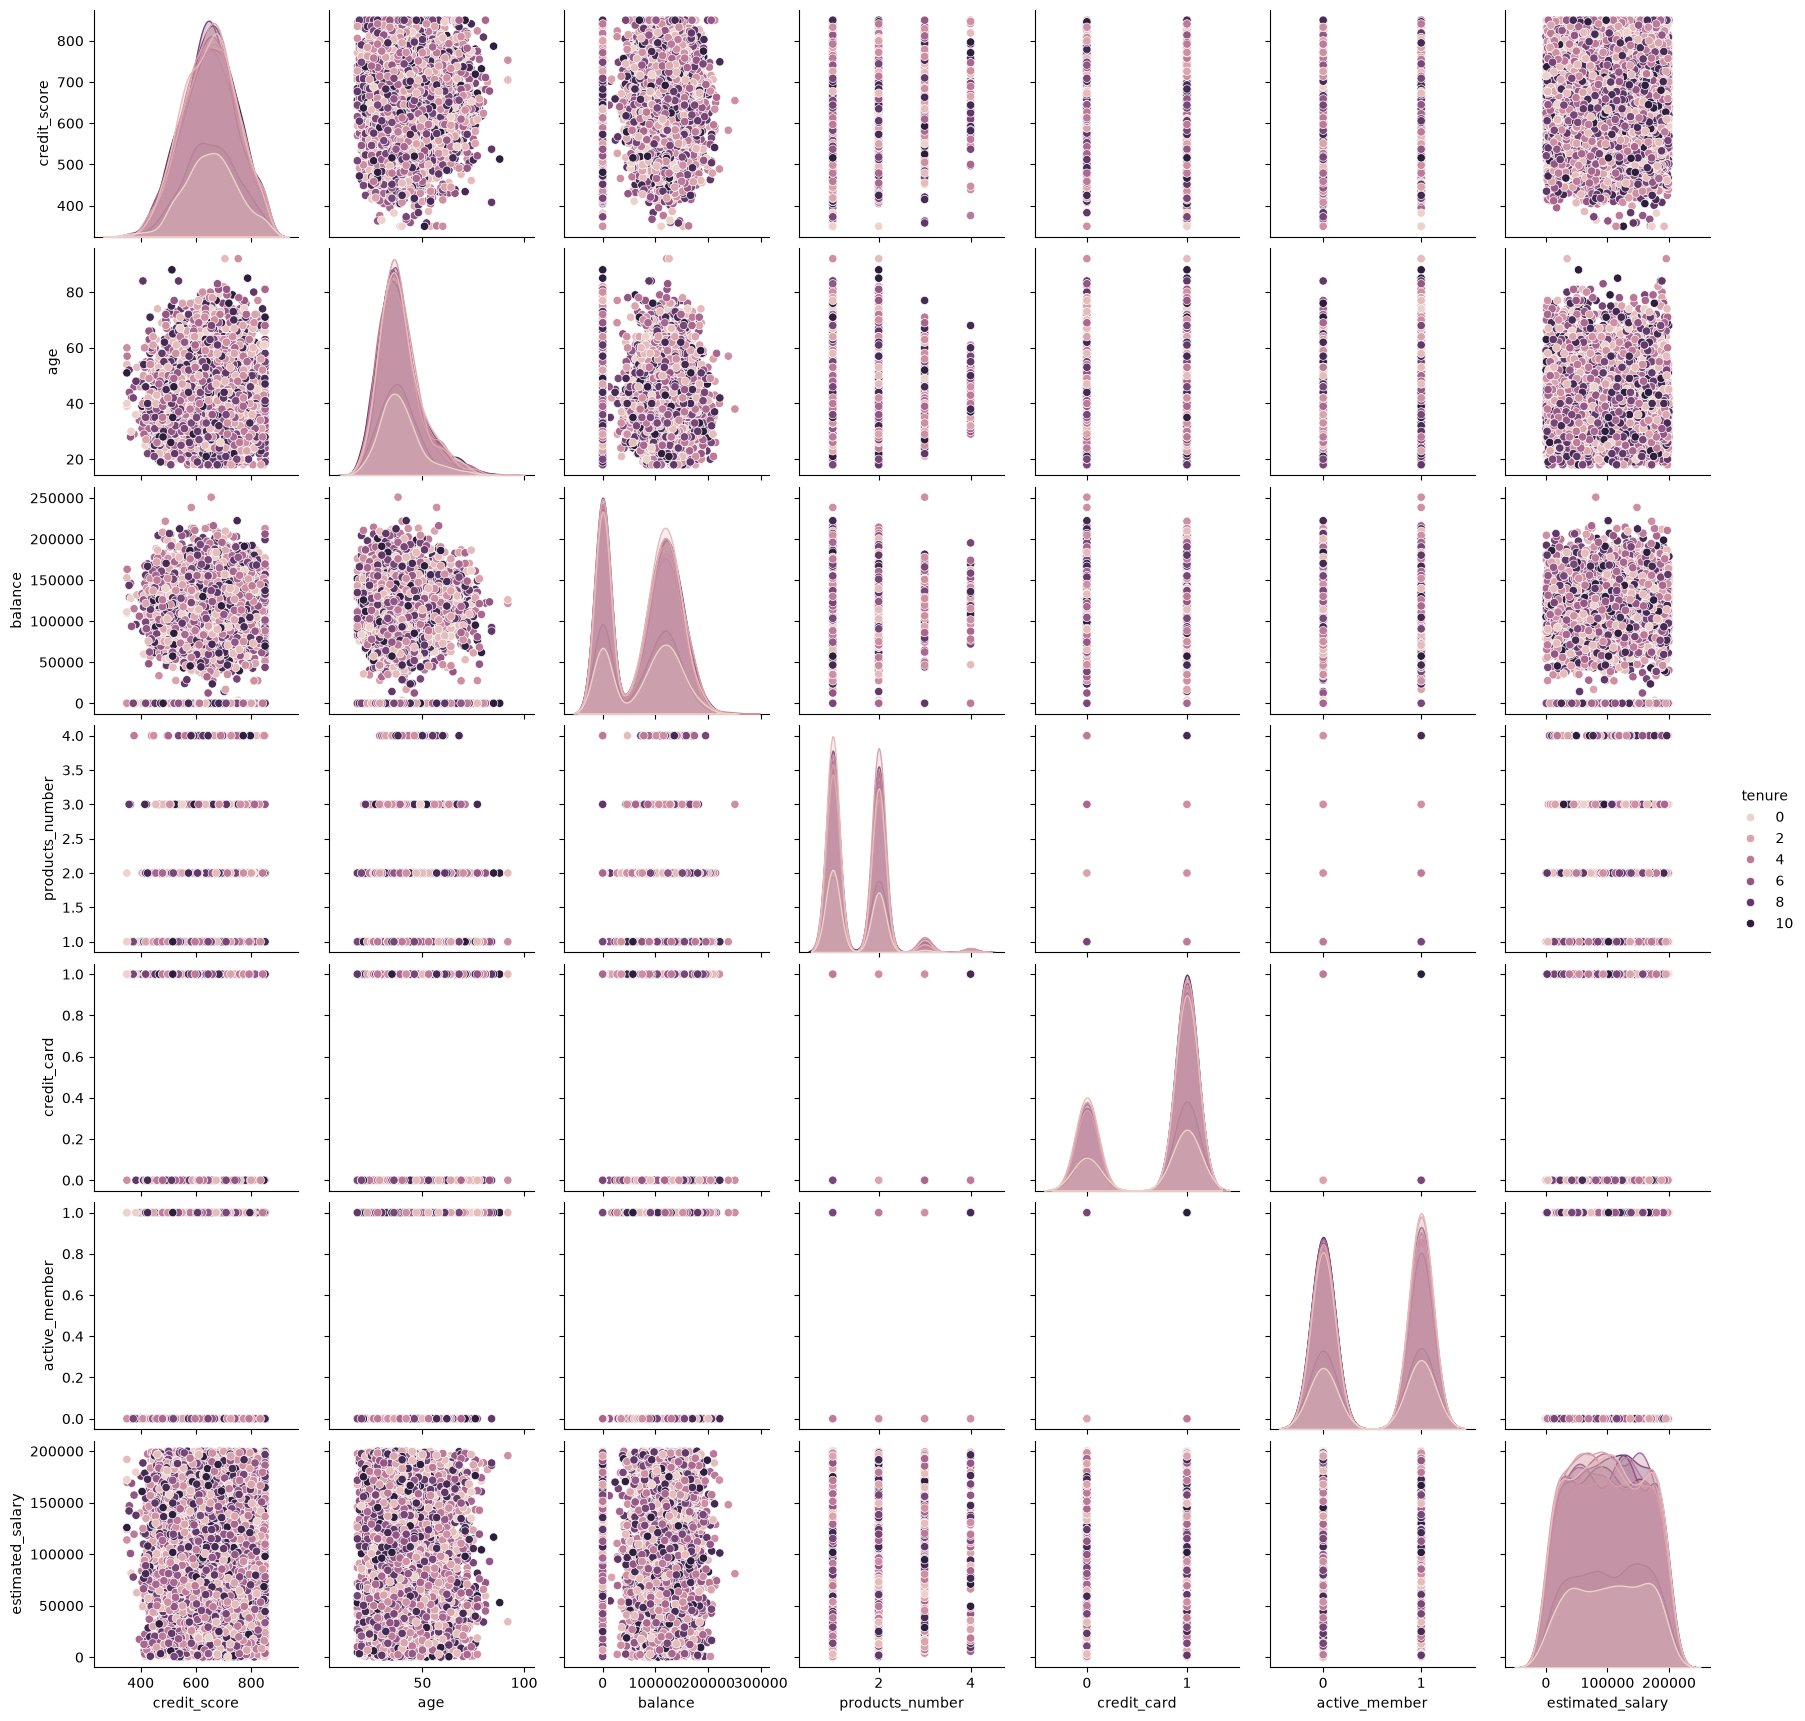

In [79]:
#Analysis using pairplot of numeric column 
sns.pairplot(df[df_col],hue='tenure')
plt.show()


- The diagonal plots show that customer salaries are evenly distributed, while balance contains a massive spike of accounts sitting at exactly zero.
- The scattered cloud formations reveal that there are no strong, simple linear relationships between your continuous variables like credit score and age.
- Columns like products number and active member appear as rigid vertical rows because they contain distinct, whole-number categories rather than fluid decimals.
- The thoroughly blended color dots show that tenure is distributed evenly across the entire dataset regardless of a customer's wealth or age profile.